# Can the tone of headlines be scored, and how well?

**In short.** A language model reads each headline and calls it positive, negative
or neutral for someone who holds the asset. A general finance model (FinBERT) was
then trained further on headlines from this app's own feed. Whether the trained model
is better was decided by a rule written down before the test, on headlines newer than
anything it had trained on. The result is printed in step 5. Either way the accuracy
on a single headline is modest, so the app shows the average of many headlines with
that accuracy beside it, and tone drives no forecast and no alert.

| Step | What it does | Code | Screen in the app |
|---|---|---|---|
| 1 | Counts how much news each market has | `radar.pipelines.sentiment` | News |
| 2 | Shows what the scores look like | `radar.models.sentiment` | News |
| 3 | Splits labelled headlines so the test is fair | `radar.models.dataset` | |
| 4 | Trains the model further | `radar.models.finetune` | |
| 5 | Tests it on headlines it never saw | `radar.models.classification` | News |

**No headline is printed here.** The labels are kept by article number only and the
text is joined in from the database while the notebook runs.

Needs `uv sync --extra nlp`. Rebuild with
`uv run python backend/scripts/build_notebooks.py 04_news`.

In [1]:
import contextlib
import io
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")  # progress-bar notices from the model library
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
from transformers.utils import logging as model_logging

model_logging.disable_progress_bar()
model_logging.set_verbosity_error()
from sqlalchemy import select

from radar.db.models import ModelRegistry, NewsArticle, NewsSentiment, NewsSymbol, SentimentAggregate
from radar.db.session import make_engine, session_scope
from radar.models import classification, dataset, evidence, finetune, sentiment
from radar.models.lexicon import DEFAULT_PATH, Lexicon
from radar.notebooks import ACCENT, BAD, GOOD, INK, MUTED, use_style
from radar.pipelines import finetune as finetune_job
from radar.pipelines import sentiment as sentiment_job
from radar.pipelines.labels import load_labels
from radar.universe import get_universe

use_style()
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
engine, universe = make_engine(), get_universe()
MARKETS = {asset.symbol: asset.name for asset in universe.primary}
# Labels drawn before gold was followed as PAX Gold carry the fund's ticker.
BY_KIND = {asset.kind: asset.name for asset in universe.primary}
NAMED = {asset.symbol: BY_KIND.get(asset.kind, asset.name) for asset in universe.assets}
TONES = {"positive": GOOD, "neutral": MUTED, "negative": BAD}
version = sentiment_job.active_version(engine)

with session_scope(engine) as session:
    scores = pd.read_sql(
        select(NewsSymbol.symbol, NewsArticle.created_at, NewsSentiment.score)
        .join(NewsArticle, NewsArticle.id == NewsSymbol.article_id)
        .join(NewsSentiment, NewsSentiment.article_id == NewsArticle.id)
        .where(
            NewsSentiment.model_version == version,
            NewsArticle.duplicate_of.is_(None),
            NewsSymbol.symbol.in_(list(MARKETS)),
        ),
        session.connection(),
    )
    daily = pd.read_sql(
        select(SentimentAggregate).where(SentimentAggregate.bucket == "1Day"), session.connection()
    )
    in_use = session.scalars(
        select(ModelRegistry).where(
            ModelRegistry.name == sentiment_job.MODEL_NAME, ModelRegistry.is_current
        )
    ).first().metrics
    trained = session.scalars(
        select(ModelRegistry)
        .where(ModelRegistry.name == finetune_job.MODEL_NAME, ModelRegistry.is_current)
        .order_by(ModelRegistry.trained_at.desc())
    ).first()
    record, model_dir, trained_at = trained.metrics, trained.artefact_path, trained.trained_at
    labelled = finetune_job.with_text(session, finetune_job.load_training_labels())
    earlier = finetune_job.with_text(session, load_labels())
scores["market"] = scores["symbol"].map(MARKETS)
labelled["market"] = labelled["symbol"].map(NAMED)
print(f"model in use: {version}; {len(scores):,} scored articles across {len(MARKETS)} markets")

model in use: finbert-radar-1; 107,184 scored articles across 3 markets


## Step 1. How much news there is

This decides everything after it. A market with one or two articles a day cannot
support a daily average worth much, and the app says so on that market's page.

,counted from,articles,a day
Bitcoin,2022-01-01,21462,12.334
Gold,2023-01-01,3303,2.402
US stocks (S&P 500),2016-01-01,82419,20.961


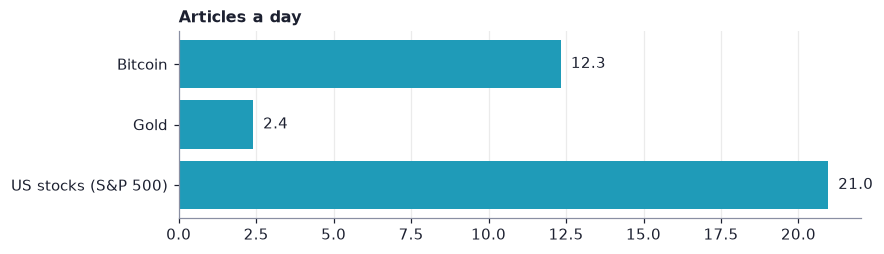

In [2]:
today = pd.Timestamp.now(tz="UTC")
amount = pd.DataFrame(
    {
        asset.name: {
            "counted from": asset.news_start,
            "articles": int((scores["symbol"] == asset.symbol).sum()),
            "a day": (scores["symbol"] == asset.symbol).sum()
            / max((today - pd.Timestamp(asset.news_start, tz="UTC")).days, 1),
        }
        for asset in universe.primary
        if asset.news_start is not None
    }
).T
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.barh(amount.index[::-1], amount["a day"][::-1].astype(float), color=ACCENT)
for place, value in enumerate(amount["a day"][::-1].astype(float)):
    ax.text(value, place, f"  {value:.1f}", va="center")
ax.set(title="Articles a day", xlabel="")
ax.grid(axis="y", visible=False)
amount

## Step 2. What the scores look like

Each article gets a score from -1 (negative) to +1 (positive).

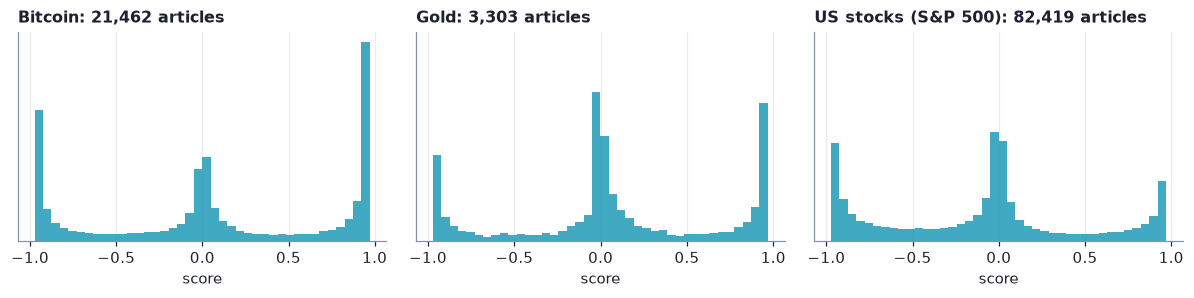

In [3]:
fig, axes = plt.subplots(1, len(MARKETS), figsize=(11, 2.8), sharey=True)
for ax, name in zip(axes, MARKETS.values()):
    part = scores.loc[scores["market"] == name, "score"]
    ax.hist(part, bins=40, color=ACCENT, alpha=0.85, density=True)
    ax.set(title=f"{name}: {len(part):,} articles", xlabel="score", yticks=[])
fig.tight_layout()

Scores pile up near -1, 0 and +1 because the model is usually sure of itself. That is
normal for this kind of model and is why the app shows a day's average, never one
article's score.

In the chart below, look at how each line moves, not where it sits. News about US
stocks reads as negative almost all the time while prices rose for years, so the
level of a market's tone says more about how its news is written than about the
market, and tone is not comparable between markets.

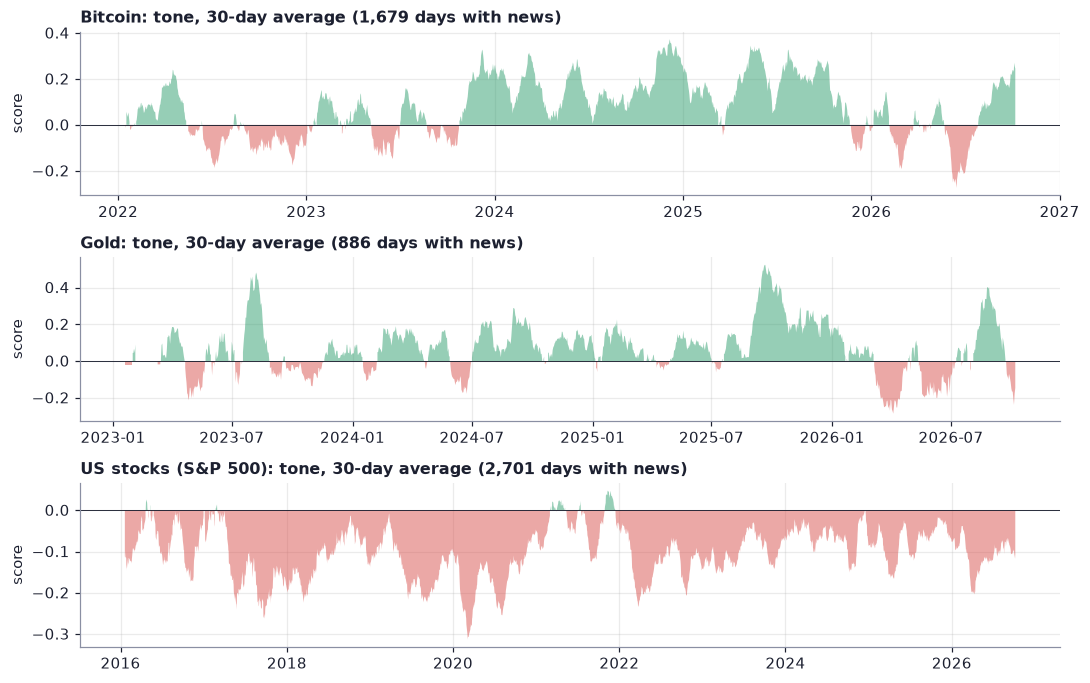

In [4]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(10, 2.1 * len(MARKETS)))
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    part = daily[daily["symbol"] == symbol].sort_values("ts").set_index("ts")
    smooth = part["score_mean"].rolling(30, min_periods=10).mean()
    ax.fill_between(smooth.index, 0, smooth.values, where=smooth.values >= 0, color=GOOD, alpha=0.5, lw=0)
    ax.fill_between(smooth.index, 0, smooth.values, where=smooth.values < 0, color=BAD, alpha=0.5, lw=0)
    ax.axhline(0, color=INK, lw=0.6)
    with_news = int((part["article_count"] > 0).sum())
    ax.set(title=f"{name}: tone, 30-day average ({with_news:,} days with news)", ylabel="score")
fig.tight_layout()

## Step 3. Labelled headlines, split so the test is fair

1,800 stored headlines were drawn at random and each was labelled positive, negative
or neutral *for a financial reader*. The labels were written by an AI model, not a
person, which the last section comes back to.

1,800 labelled headlines; labelled by: ['claude']


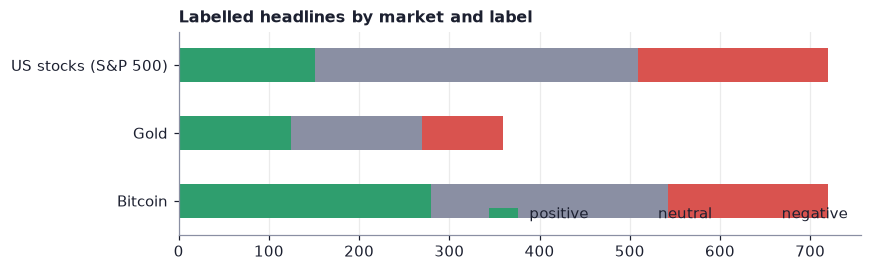

In [5]:
print(f"{len(labelled):,} labelled headlines; labelled by: {sorted(set(labelled['labelled_by']))}")
counts = pd.crosstab(labelled["market"], labelled["sentiment"])[list(TONES)]
ax = counts.plot.barh(stacked=True, color=list(TONES.values()), figsize=(8, 2.4))
ax.set(title="Labelled headlines by market and label", ylabel="")
ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="lower right");

Testing a model on something it has in effect already seen makes it look better than
it is. Three guards are used.

1. **Split by time, not at random.** The model trains on the oldest headlines, its
   settings are chosen on later ones, and it is tested on the newest. That is how it
   is used: on news that arrives after it was trained.
2. **No near-copies across the parts.** Many headlines are templates that differ only
   in a number. Each is reduced to a key with numbers removed, and a key may appear
   once in the whole set.
3. **A test part used once.** Choices are made on the middle part. The test part is
   scored only after every choice is made.

In [6]:
parts = {name: labelled[labelled["split"] == name] for name in dataset.SPLITS}
finetune_job.check_dataset(labelled, earlier)  # raises if any guard is broken
keys = labelled["headline"].map(dataset.headline_key)
guards = {
    "articles appearing twice": int(labelled["article_id"].duplicated().sum()),
    "near-copies appearing twice": int(keys.duplicated().sum()),
    "articles shared with the earlier 200-headline sample": len(
        set(labelled["article_id"]) & set(earlier["article_id"])
    ),
    "near-copies shared with that sample": len(set(keys) & set(earlier["headline"].map(dataset.headline_key))),
    "training headlines newer than the middle part": int(
        parts["train"]["created_at"].max() >= parts["validation"]["created_at"].min()
    ),
    "middle-part headlines newer than the test part": int(
        parts["validation"]["created_at"].max() >= parts["test"]["created_at"].min()
    ),
}
pd.Series(guards, name="count (every one must be 0)").to_frame()

,count (every one must be 0)
articles appearing twice,0
near-copies appearing twice,0
articles shared with the earlier 200-headline sample,0
near-copies shared with that sample,0
training headlines newer than the middle part,0
middle-part headlines newer than the test part,0


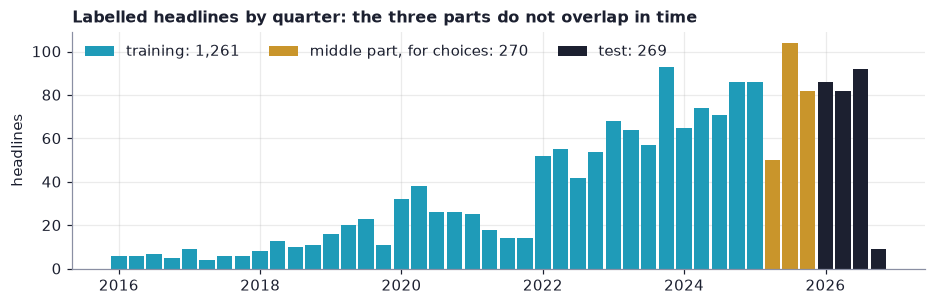

In [7]:
fig, ax = plt.subplots(figsize=(10, 2.8))
shades = {"train": ACCENT, "validation": "#c9952b", "test": INK}
words = {"train": "training", "validation": "middle part, for choices", "test": "test"}
for name, part in parts.items():
    quarters = part["created_at"].dt.tz_localize(None).dt.to_period("Q").dt.to_timestamp()
    per = quarters.value_counts().sort_index()
    ax.bar(per.index, per.values, width=80, color=shades[name], label=f"{words[name]}: {len(part):,}")
ax.set(title="Labelled headlines by quarter: the three parts do not overlap in time", ylabel="headlines")
ax.legend(ncol=3);

## Step 4. Training

The settings are the usual ones for a model of this size and were fixed before any
result was seen. After each pass over the training headlines the model is scored on
the middle part, and the pass with the best score there is kept.

Training is run by `uv run radar finetune`, which stores its record. This notebook
reads that record, so the numbers are the ones behind the model the app uses.

trained 2026-10-05 from ProsusAI/finbert
1,261 training and 270 middle-part headlines; learning rate 2e-05, batches of 16, seed 13


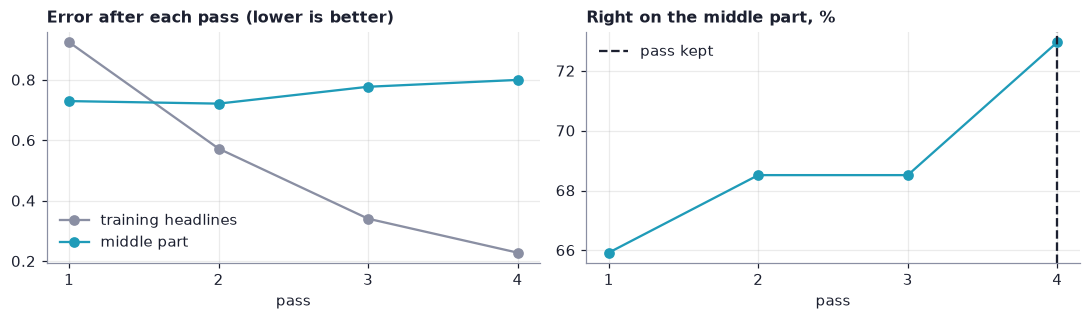

In [8]:
training = record["training"]
print(f"trained {trained_at:%Y-%m-%d} from {training['base_model']}")
print(
    f"{training['n_train']:,} training and {training['n_validation']:,} middle-part headlines; "
    f"learning rate {training['learning_rate']}, batches of {training['batch_size']}, seed {training['seed']}"
)
passes = pd.DataFrame(training["epochs"]).set_index("epoch")
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(passes.index, passes["train_loss"], marker="o", color=MUTED, label="training headlines")
axes[0].plot(passes.index, passes["validation_loss"], marker="o", color=ACCENT, label="middle part")
axes[0].set(title="Error after each pass (lower is better)", xlabel="pass", xticks=passes.index)
axes[0].legend()
axes[1].plot(passes.index, passes["validation_accuracy"] * 100, marker="o", color=ACCENT)
axes[1].axvline(training["best_epoch"], color=INK, ls="--", label="pass kept")
axes[1].set(title="Right on the middle part, %", xlabel="pass", xticks=passes.index)
axes[1].legend()
fig.tight_layout()

Error on the training headlines keeps falling because the model is memorising them.
The middle part is the honest line: once it stops falling, further passes fit noise.

## Step 5. The test

### First test: the newest labelled headlines

Three methods label the same headlines: the general model, the trained one, and a
count of positive and negative words from a finance word list.

In [9]:
test = parts["test"]
truth, texts = test["sentiment"].tolist(), test["text"].tolist()
general = sentiment.FinbertScorer()
tuned = sentiment.FinbertScorer(model_dir, finetune.MODEL_VERSION)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    # loading the models prints download notices, which are not results
    said = {
        "general model": [sentiment.LABELS[i] for i in general.probabilities(texts).argmax(axis=1)],
        "trained model": [sentiment.LABELS[i] for i in tuned.probabilities(texts).argmax(axis=1)],
    }
if DEFAULT_PATH.is_file():
    said["word list"] = Lexicon.load().labels(texts)
results = {name: classification.report(truth, labels, sentiment.LABELS) for name, labels in said.items()}
pd.DataFrame(
    {
        name: {"headlines": r.n, "right, %": r.accuracy * 100, "balanced score (macro F1)": r.macro_f1}
        for name, r in results.items()
    }
).T

,headlines,"right, %",balanced score (macro F1)
general model,269.000,58.736,0.593
trained model,269.000,63.569,0.638
word list,269.000,48.327,0.475


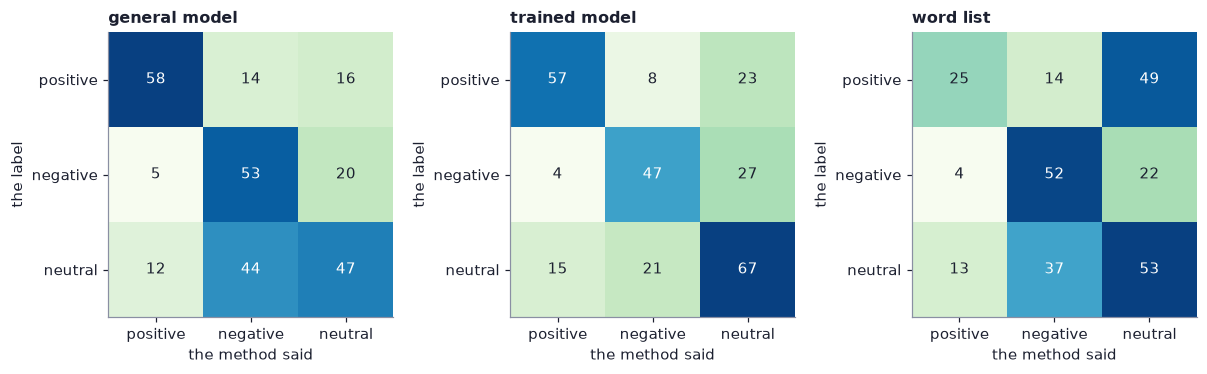

In [10]:
order = list(sentiment.LABELS)
fig, axes = plt.subplots(1, len(said), figsize=(3.7 * len(said), 3.4))
for ax, (name, predicted) in zip(np.atleast_1d(axes), said.items()):
    grid = pd.crosstab(pd.Categorical(truth, order), pd.Categorical(predicted, order), dropna=False).to_numpy()
    ax.imshow(grid, cmap="GnBu")
    ax.set(xticks=range(3), yticks=range(3), xticklabels=order, yticklabels=order, xlabel="the method said", ylabel="the label", title=name)
    ax.grid(False)
    for row in range(3):
        for column in range(3):
            ax.text(column, row, int(grid[row, column]), ha="center", va="center", color="white" if grid[row, column] > grid.max() / 2 else INK)
fig.tight_layout()

Each row is what the label says and each column what the method said. Agreement is on
the diagonal, so a good method has its large numbers there.

A higher score on a few hundred headlines can be luck. The check below (McNemar's
test) looks only at headlines where one model was right and the other wrong, and asks
how likely so lopsided a split would be if the two were equal.

In [11]:
first_check = classification.mcnemar(truth, said["general model"], said["trained model"])
adopted, reason = finetune_job.decide(results["general model"], results["trained model"], first_check)
pd.Series(
    {
        "headlines": first_check.n,
        "only the general model was right": first_check.only_first_right,
        "only the trained model was right": first_check.only_second_right,
        "could be luck (p)": round(first_check.p_value, 4),
        "trained model adopted on this test": adopted,
        "why": reason,
    },
    name="first test",
).to_frame()

,first test
headlines,269
only the general model was right,20
only the trained model was right,33
could be luck (p),0.098
trained model adopted on this test,False
why,difference_not_measurable


### Second test: larger, and fixed in advance

The first test was too small to settle it. Changing the model and trying again would
have turned the test into a place to tune, so the **same saved model** was scored on
a fresh set of headlines instead:

- all newer than every headline used in training or for choices;
- sharing no article and no near-copy with anything labelled before;
- labelled before either model had scored them;
- with the rule for adopting the model written down and committed before the labels
  existed.

,"right, %",from,to
general model,51.600,47.900,55.300
trained model,61.100,57.500,64.700
word list,43.600,39.900,47.300


,second test
headlines,700
from,2026-01-26
to,2026-10-05
only the general model was right,45
only the trained model was right,112
could be luck (p),8.9e-08
decision,measurably_better
trained model adopted,True


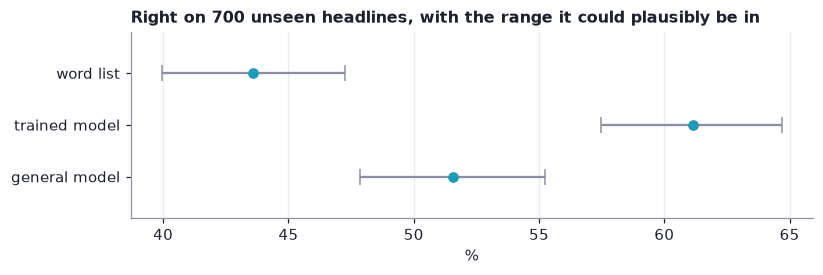

In [12]:
second = record.get("replication")
if second is None:
    print("The larger test has not been run.")
else:
    rows = {}
    for name, key in (("general model", "base"), ("trained model", "fine_tuned"), ("word list", "baseline")):
        if key not in second:
            continue
        low, high = evidence.share_interval(second[key]["accuracy"], second["n"])
        rows[name] = {"right, %": second[key]["accuracy"] * 100, "from": low * 100, "to": high * 100}
    ranges = pd.DataFrame(rows).T
    fig, ax = plt.subplots(figsize=(8, 2.2))
    span = [ranges["right, %"] - ranges["from"], ranges["to"] - ranges["right, %"]]
    ax.errorbar(ranges["right, %"], ranges.index, xerr=span, fmt="o", capsize=5, color=ACCENT, ecolor=MUTED)
    ax.set(title=f"Right on {second['n']} unseen headlines, with the range it could plausibly be in", xlabel="%")
    ax.grid(axis="y", visible=False)
    ax.margins(y=0.4)
    check = second["comparison"]
    display(ranges.round(1))
    display(
        pd.Series(
            {
                "headlines": second["n"],
                "from": second["first"],
                "to": second["last"],
                "only the general model was right": check["only_first_right"],
                "only the trained model was right": check["only_second_right"],
                "could be luck (p)": f"{check['p_value']:.2g}",
                "decision": record["reason"],
                "trained model adopted": record["adopted"],
            },
            name="second test",
        ).to_frame()
    )

Where the two ranges do not overlap, the gain is not luck. Note what the test does
*not* say: the figure for "right" is still modest. Many headlines get a different
label from the labeller's.

### What kind of mistakes

Calling a mildly positive headline neutral is a small error. Calling a negative one
positive is the kind that would mislead a reader.

In [13]:
if second is not None and "direction" in second:
    kinds = pd.DataFrame({"general model": second["direction_base"], "trained model": second["direction"]}).T
    kinds["backwards, %"] = kinds["opposite_rate"] * 100
    display(
        kinds.rename(columns={"n": "headlines", "opposite": "backwards", "both_polar": "both took a side"})[
            ["headlines", "backwards", "backwards, %", "both took a side"]
        ]
    )
if second is not None and "by_symbol" in second:
    each = pd.DataFrame(second["by_symbol"]).T
    each.index = each.index.map(lambda symbol: NAMED.get(symbol, symbol))
    each[["base", "fine_tuned"]] *= 100
    display(each.rename(columns={"n": "headlines", "base": "general, right %", "fine_tuned": "trained, right %"}))

,headlines,backwards,"backwards, %",both took a side
general model,700.000,79.000,11.286,318.000
trained model,700.000,49.000,7.000,302.000


,headlines,"general, right %","trained, right %"
Gold,140.000,51.429,58.571
US stocks (S&P 500),280.000,47.143,57.143
Bitcoin,280.000,56.071,66.429


## What to take from this

- Which model is used follows a rule fixed in advance: more often right on unseen
  headlines **and** a gap too large to be luck. The first test was too small to tell;
  the second decides, and its outcome is in the table above.
- Being right on a single headline is modest either way. The app therefore shows that
  figure beside the tone, and leans on the average of many articles.
- Tone describes the news around a holding. It drives no forecast and no alert: a
  separate test found it does not improve the forecast of movement size, and a study
  of tone against price found that news mostly follows the move it describes (both in
  `07_what_we_tested`).
- Agreement here is with one labeller, and that labeller is an AI model. A person
  might label some headlines differently, and a model trained to match these labels
  inherits their habits. Labels from a person are still owed.
- All articles come from one provider. Gold's news is the news written about the
  gold fund, read for PAX Gold, because the coin has almost none of its own.
- With a few hundred test headlines per market, the per-market figures are rough.